<a href="https://colab.research.google.com/github/sherjahong1r/Machine-Learning-Lessons/blob/main/01_ML_15_k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning.

# Clustering

Klasterlash unsupervised learningning bir ko'rinishi hisoblanadi.

Klasterlash yordamida yorliqlanmagan (label yo'q) ma'lumotlarni klasterlarga ajratamiz.

Klasterdagi boshqa obyektlarga o'xshash va boshqa klasterlardagi obyektlarga o'xshamaydigan obyektlar guruhi.

**Klasterlash qayerda ishlatiladi?**
- SAVDO VA MARKETING
    - Mijozalr xarid odatlarini aniqlash
    - Tavsiya tizimlari
- BANK VA MOLIYA
    - Firibgarlikni aniqlash
    - Customer churn
- SUG’URTA
    - Firibgarlikni aniqlash
    - Mijozlarning riskini baholash
- NASHRIYOT
    - Yangiliklarni mavzu bo’yicha saralash
    - Tavsiya tizimlari
- TIBBIYOT
    - Kasallarning odatlarini aniqlash
- BIOLOGIYA
    - Genetik markerlarni tahlil qilish orqali qarindoshlikni aniqlash
    
## Amaliyot
Ushbu amaliyotda biz tasodifiy nuqtalar yaratamiz va bu nuqtalarni klasterlaymiz. Maqsad: klasterlash algoritmi qanday ishlashini ko'rish:

In [65]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

Tasodifiy nuqtalar klasterini yaratish uchun `make_blobs` funksiyasidan foydalanamiz. Bu funksiya quyidagi parametrlarni qabul qiladi:
- `n_samples` - nuqtalar soni
- `centers` - klasterlar markazi (sentroid) koordinatalari
-`cluster_std` - markazdan standart og'ish

`make_blobs` funksiyasi nuqtalarning `x` va `y` koordinatalarini qaytaradi.

In [66]:
np.random.seed(0)
centroids = [[3,3], [-3, -2], [2, -3], [0, 0]]
X, y = make_blobs(n_samples=5000, centers=centroids, cluster_std=0.8)

# np.random.seed(0): Bu qator NumPy ning tasodifiy sonlar generatori uchun 'urug'ni (seed) 0 ga o'rnatadi.
# Bu shuni anglatadiki, kod har safar ishga tushirilganda bir xil tasodifiy ma'lumotlar
# yaratiladi, bu esa natijalarni takrorlash imkonini beradi.
# centroids = [[3,3], [-3, -2], [2, -3], [0, 0]]: Bu qator to'rtta klaster uchun markaziy nuqtalarni
# (sentroidlarni) belgilaydi. Har bir ichki ro'yxat [x, y] sentroidning koordinatalarini ifodalaydi.
# X, y = make_blobs(n_samples=5000, centers=centroids, cluster_std=0.8):
# make_blobs - bu scikit-learn kutubxonasidan klasterlash uchun izotropik Gauss blob'larini yaratish uchun ishlatiladigan funksiya.
# n_samples=5000: Jami 5000 ta ma'lumot nuqtasi yaratilishini ko'rsatadi.
# centers=centroids: Avval belgilangan centroids ro'yxatini klasterlar markazlari sifatida
# ishlatadi. Bu har bir sentroid atrofida bittadan, jami 4 ta klaster yaratilishini anglatadi.
# cluster_std=0.8: Klasterlarning standart og'ishini belgilaydi. Kichikroq qiymat nuqtalarning
# o'z sentroidlariga yaqinroq bo'lishini, kattaroq qiymat esa ularning ko'proq tarqalishini anglatadi.
# X: Yaratilgan ma'lumot nuqtalarini (xususiyatlarni) o'z ichiga oladi, odatda 2D massiv bo'lib, har bir qator
# namunani va har bir ustun xususiyatni (masalan, x va y koordinatalari) ifodalaydi.
# y: Har bir namuna uchun haqiqiy yorliqlarni (klaster biriktirmalarini) o'z ichiga oladi. Bu klasterlash
# algoritmlarini baholash uchun foydali, ammo real dunyo nazoratsiz o'rganishida ko'pincha noma'lum bo'ladi.


Nuqtalarni chizamiz:

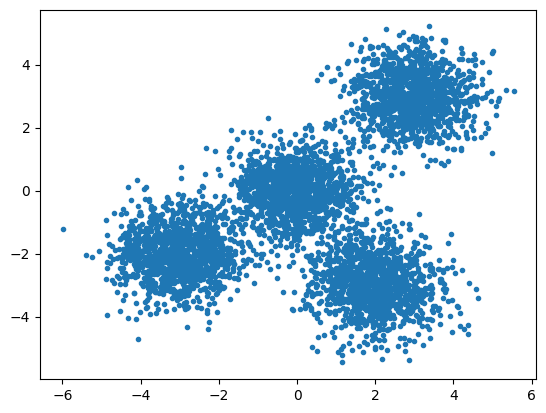

In [67]:
plt.scatter(X[:, 0], X[:, 1], marker='.')
plt.show()
# bu kod X massividagi ma'lumot nuqtalarini ikki o'lchovli grafikda, har bir nuqtani nuqta shaklida tasvirlaydi.

### k-means algoritmi
`KMeans` funksiyasi quyidagi parametrlarni qabul qiladi:
- `init` - sentrodilarni tanlash usuli (`k-means++` yoki `random`)
- `n_clusters` - klastertlar soni
- `n_init` - algoritmni necha marta ishga tushirish (turli sentroidlar bilan qayta-qayta ishga tushirib, modelni qurishni boshlash uchun eng yaxshi sentroidlar tanlanadi)

`KMeans` boshqa parametrlari haqida rasmiy sahifasidan ma'lumot olasiz: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

In [68]:
k_means = KMeans(init = "random", n_clusters = 4, n_init = 15)

Modelni tarbiyalaymiz

In [69]:
k_means.fit(X)

KMeans(init='random', n_clusters=4, n_init=15)

Nuqtalar klasterlandi. Klaster raqamini ko'rish uchun `.labels_` parametriga murojaat qilamiz.

In [70]:
k_means.labels_

array([3, 1, 1, ..., 2, 3, 3], dtype=int32)

Klaster markazlarini ko'rich uchun `.cluster_centers_` parametriga murojaat qilamiz.

In [71]:
k_means.cluster_centers_

array([[-3.05006801e-02,  1.12353254e-03],
       [ 1.99348887e+00, -3.01067931e+00],
       [ 2.97795387e+00,  2.99317691e+00],
       [-3.01979724e+00, -1.99489798e+00]])

Algoritm topgan klaster markazlarini, biz avvaldan bergan markazlar bilan solishtiramiz:

In [72]:
print(centroids)

[[3, 3], [-3, -2], [2, -3], [0, 0]]


Deyarli bir xil. Butunlab ko'ramiz:

In [73]:
print(np.round(k_means.cluster_centers_))

[[-0.  0.]
 [ 2. -3.]
 [ 3.  3.]
 [-3. -2.]]


### Grafik chizamiz

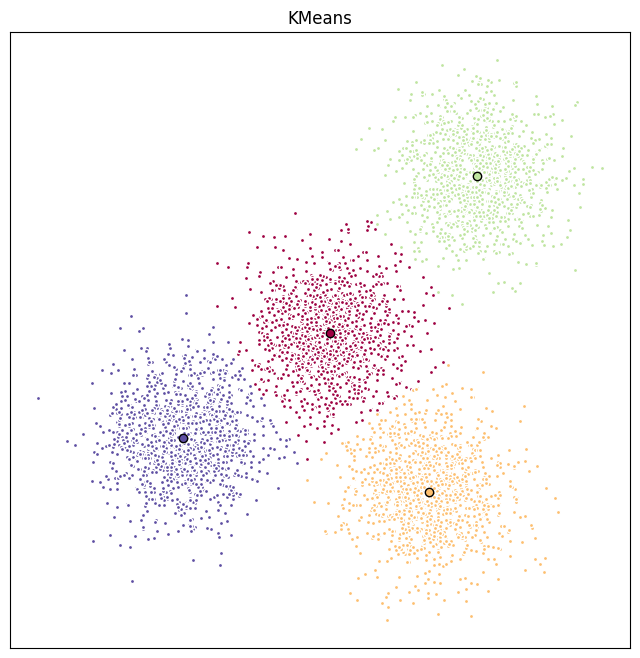

In [74]:
fig = plt.figure(figsize=(8, 8))
# Har bir klaster uchun alohida rang
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means.labels_))))
#Klasterlar soniga qarab noyob ranglar palitrasini yaratadi.

ax = fig.add_subplot(1, 1, 1)
#Grafik uchun bitta sub-grafik (axes) qo'shadi.

for k, col in zip(range(len([[3,3], [-3, -2], [2, -3], [0, 0]])), colors):
#Har bir klaster uchun takrorlanishni boshlaydi.

    # Create a list of all data points, where the data points that are
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means.labels_ == k)
#Joriy klasterga tegishli nuqtalarni belgilaydi.

    # Define the centroid, or cluster center.
    cluster_center = k_means.cluster_centers_[k]
#Joriy klaster markazini oladi.

    # Plots the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')
#Joriy klaster nuqtalarini tegishli rangda chizadi.

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
#Joriy klaster markazini belgilangan rangda va qora hoshiya bilan chizadi.

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())
# X-o'qidagi belgilarini o'chiradi.

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()

## VAZIFA
`KMeans` algoritmini turli `k` (klasterlar soni) va boshqa `init` parametri (`k-means++`) bilan ishga tushirib ko'ring.

# New section

### `k-means++` va boshqa `k` qiymati bilan KMeans

Endi `init='k-means++'` va klasterlar sonini (`n_clusters`) boshqa qiymatga o'rnatib (`k=3` ga o'rnatamiz) modelni sinab ko'ramiz.

## yuqoridagi grafikda `"init = random"` dan foydalanilgan edi endi biz pastda

## init = `"k-means++"` metodidan foydalanamiz

In [75]:
k_means_2 = KMeans(init = "k-means++", n_clusters = 3, n_init = 15, random_state=0)

k_means_2.fit(X)

print("Klaster raqamlari (k_means_2.labels_):\n", k_means_2.labels_)
print("\nKlaster markazlari (k_means_2.cluster_centers_):\n", k_means_2.cluster_centers_)

Klaster raqamlari (k_means_2.labels_):
 [0 2 2 ... 1 0 0]

Klaster markazlari (k_means_2.cluster_centers_):
 [[-1.84840051 -1.14875843]
 [ 2.78117788  2.80263657]
 [ 1.89467587 -2.7636292 ]]


In [76]:
print(np.round(k_means_2.cluster_centers_))
# Butunlab ko'ramiz

[[-2. -1.]
 [ 3.  3.]
 [ 2. -3.]]


### Yangi KMeans modelini grafikda tasvirlash

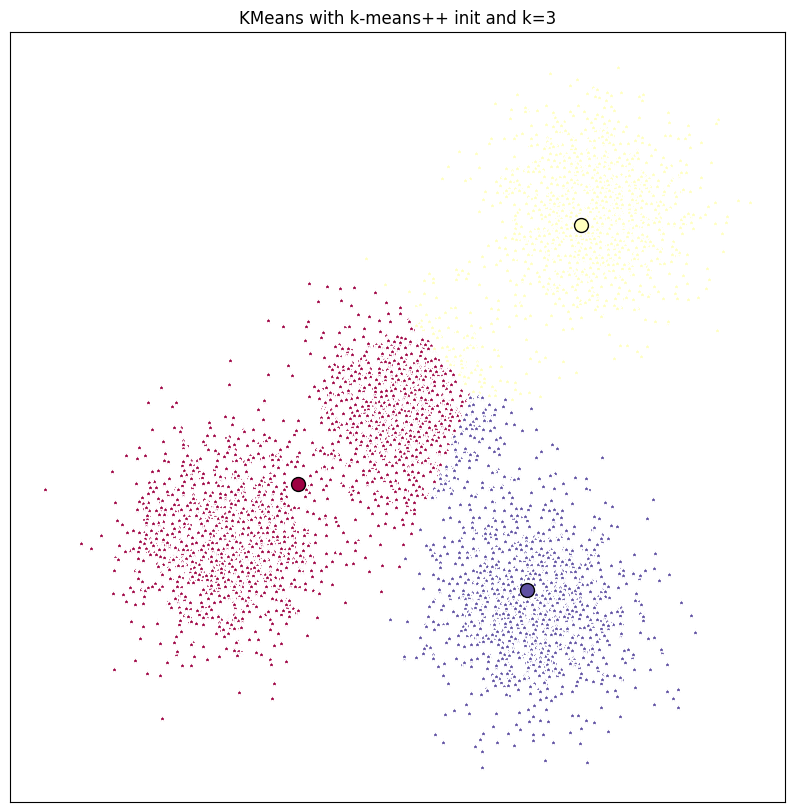

In [77]:
fig_second = plt.figure(figsize=(10, 10))
# Har bir klaster uchun alohida rang
colors_second = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means_2.labels_))))
ax_2 = fig_second.add_subplot(1, 1, 1)

for k_2, col_2 in zip(range(k_means_2.n_clusters), colors_second):
    my_members_2 = (k_means_2.labels_ == k_2)
    cluster_center_2 = k_means_2.cluster_centers_[k_2]

    ax_2.plot(X[my_members_2, 0], X[my_members_2, 1], 'w', markerfacecolor=col_2, marker='*')
    ax_2.plot(cluster_center_2[0], cluster_center_2[1], 'o', markerfacecolor=col_2,  markeredgecolor='k', markersize=10)

ax_2.set_title('KMeans with k-means++ init and k=3')
ax_2.set_xticks(())
ax_2.set_yticks(())
plt.show()

# **New section**

## pastda `6` ta clasterga ajratib ko'ramiz

In [78]:
k_means_3 = KMeans(init = "random", n_clusters = 6, n_init = 30)


In [79]:
k_means_3.fit(X)


KMeans(init='random', n_clusters=6, n_init=30)

In [80]:
k_means_3.labels_


array([3, 1, 0, ..., 4, 3, 3], dtype=int32)

In [81]:
k_means_3.cluster_centers_


array([[ 1.38786026, -2.42490529],
       [ 2.41137218, -3.38349231],
       [ 0.43255107,  0.30960075],
       [-3.0920297 , -2.04886345],
       [ 2.98911011,  3.00701465],
       [-0.83618337, -0.37812217]])

In [82]:
print(centroids)

[[3, 3], [-3, -2], [2, -3], [0, 0]]


In [83]:
print(np.round(k_means_3.cluster_centers_))

[[ 1. -2.]
 [ 2. -3.]
 [ 0.  0.]
 [-3. -2.]
 [ 3.  3.]
 [-1. -0.]]


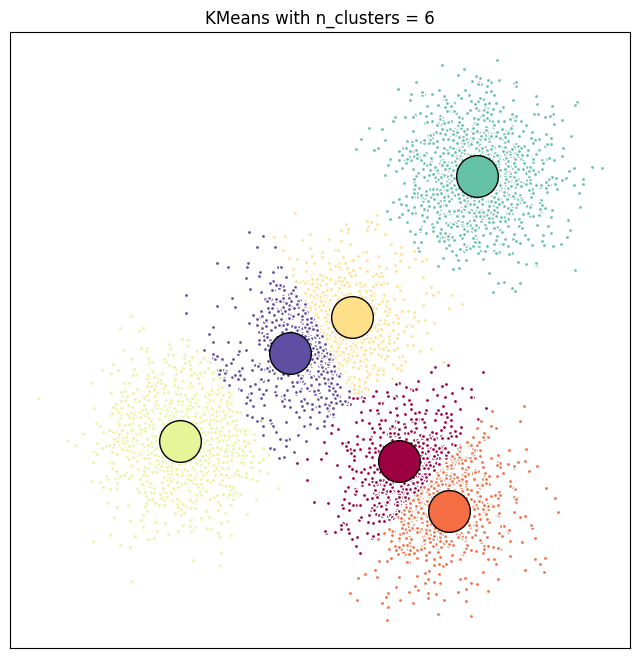

In [84]:
fig = plt.figure(figsize=(8, 8))
# Har bir klaster uchun alohida rang
colors_3 = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means_3.labels_))))
#Klasterlar soniga qarab noyob ranglar palitrasini yaratadi.

ax_3 = fig.add_subplot(1, 1, 1)
#Grafik uchun bitta sub-grafik (axes) qo'shadi.

for k_3, col_3 in zip(range(k_means_3.n_clusters), colors_3):
#Har bir klaster uchun takrorlanishni boshlaydi.

    my_members_3 = (k_means_3.labels_ == k_3)
#Joriy klasterga tegishli nuqtalarni belgilaydi.

    cluster_center_3 = k_means_3.cluster_centers_[k_3]
#Joriy klaster markazini oladi.

    ax_3.plot(X[my_members_3, 0], X[my_members_3, 1], 'w', markerfacecolor=col_3, marker='.')
#Joriy klaster nuqtalarini tegishli rangda chizadi.

    ax_3.plot(cluster_center_3[0], cluster_center_3[1], 'o', markerfacecolor=col_3,  markeredgecolor='k', markersize=30)
#Joriy klaster markazini belgilangan rangda va qora hoshiya bilan chizadi.

ax_3.set_title('KMeans with n_clusters = 6')
ax_3.set_xticks(())
# X-o'qidagi belgilarini o'chiradi.
ax_3.set_yticks(())
plt.show()